In [48]:
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv("messy_employee_dataset.csv")

In [50]:
df.head()

,EmployeeID,Name,Gender,Age,City,Department,Salary,Experience,PerformanceScore,WorkHours
0,1,Employee_1,Female,29.0,Pune,Sales,102709.0,19,60,39
1,2,Employee_2,Male,59.0,Chennai,Marketing,31573.0,20,75,48
2,3,Employee_3,Female,60.0,Kolkata,IT,114100.0,11,95,35
3,4,Employee_4,Female,36.0,Kochi,IT,81340.0,25,72,41
4,5,Employee_5,Male,35.0,Bangalore,nan,33637.0,13,79,54


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EmployeeID        1050 non-null   int64  
 1   Name              1050 non-null   object 
 2   Gender            1050 non-null   object 
 3   Age               997 non-null    float64
 4   City              1050 non-null   object 
 5   Department        1050 non-null   object 
 6   Salary            998 non-null    object 
 7   Experience        1050 non-null   int64  
 8   PerformanceScore  1050 non-null   int64  
 9   WorkHours         1050 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 82.2+ KB


In [52]:
df.describe()

,EmployeeID,Age,Experience,PerformanceScore,WorkHours
count,1050.000000,997.000000,1050.000000,1050.000000,1050.000000
mean,502.492381,40.826479,15.959048,80.460952,44.841905
std,288.415170,11.442232,8.700024,12.141637,6.093156
min,1.000000,21.000000,1.000000,60.000000,35.000000
25%,255.250000,31.000000,8.000000,70.000000,40.000000
50%,502.500000,41.000000,17.000000,81.000000,45.000000
75%,752.000000,50.000000,23.000000,91.000000,50.000000
max,1000.000000,60.000000,30.000000,100.000000,55.000000


In [53]:
df.isnull().sum()

EmployeeID           0
Name                 0
Gender               0
Age                 53
City                 0
Department           0
Salary              52
Experience           0
PerformanceScore     0
WorkHours            0
dtype: int64

In [54]:
df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")
df["Salary"].fillna(df["Salary"].mean(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_12444\3853645187.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Salary"].fillna(df["Salary"].mean(), inplace=True)


In [55]:
df.isnull().sum()

EmployeeID           0
Name                 0
Gender               0
Age                 53
City                 0
Department           0
Salary               0
Experience           0
PerformanceScore     0
WorkHours            0
dtype: int64

In [56]:
df["Age"].fillna(df["Age"].mean(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_12444\1809399462.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)


In [57]:
df.drop_duplicates(inplace=True)

In [58]:
df.isnull().sum()

EmployeeID          0
Name                0
Gender              0
Age                 0
City                0
Department          0
Salary              0
Experience          0
PerformanceScore    0
WorkHours           0
dtype: int64

In [59]:
df.shape

(1004, 10)

In [60]:
df.groupby("Department")["Salary"].mean()

Department
Finance       77286.314167
HR            75317.705521
IT            75745.567671
Marketing     78480.246822
Sales         74776.348031
nan           75027.770360
Name: Salary, dtype: float64

In [61]:
df["Department"] = df["Department"].str.strip()

df["Department"] = df["Department"].replace("nan","clean")

In [62]:
df.groupby("Department")["Salary"].mean()

Department
Finance      77286.314167
HR           75317.705521
IT           75745.567671
Marketing    78480.246822
Sales        74776.348031
clean        75027.770360
Name: Salary, dtype: float64

In [63]:
df["City"].value_counts()

City
Pune         147
Chennai      128
Kolkata      127
Kochi        125
Bangalore    125
Mumbai       113
Delhi        107
Hyderabad    102
bangalore      5
pune           5
mumbai         5
chennai        3
kochi          3
kolkata        3
hyderabad      3
delhi          3
Name: count, dtype: int64

In [64]:
df[df["Salary"] > 100000]

,EmployeeID,Name,Gender,Age,City,Department,Salary,Experience,PerformanceScore,WorkHours
0,1,Employee_1,Female,29.000000,Pune,Sales,102709.0,19,60,39
2,3,Employee_3,Female,60.000000,Kolkata,IT,114100.0,11,95,35
6,7,Employee_7,Female,42.000000,Hyderabad,Marketing,113465.0,30,98,50
12,13,Employee_13,Male,31.000000,Delhi,Finance,105016.0,12,91,49
20,21,Employee_21,Female,56.000000,Pune,Finance,110380.0,23,60,39
...,...,...,...,...,...,...,...,...,...,...
974,975,Employee_975,Female,40.000000,Pune,HR,104633.0,30,73,44
976,977,Employee_977,Male,57.000000,Kolkata,IT,101425.0,27,91,46
982,983,Employee_983,Female,40.826479,Kochi,IT,104469.0,2,73,49
995,996,Employee_996,Female,32.000000,Mumbai,Marketing,109135.0,19,77,44


In [65]:
df.groupby("Gender")["PerformanceScore"].mean()

Gender
Female    80.314168
Male      80.330754
Name: PerformanceScore, dtype: float64

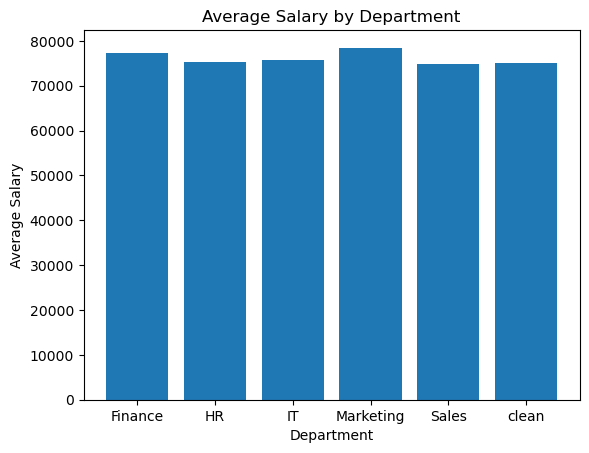

In [66]:
dept_salary = df.groupby("Department")["Salary"].mean()

plt.bar(dept_salary.index, dept_salary.values)

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.show()

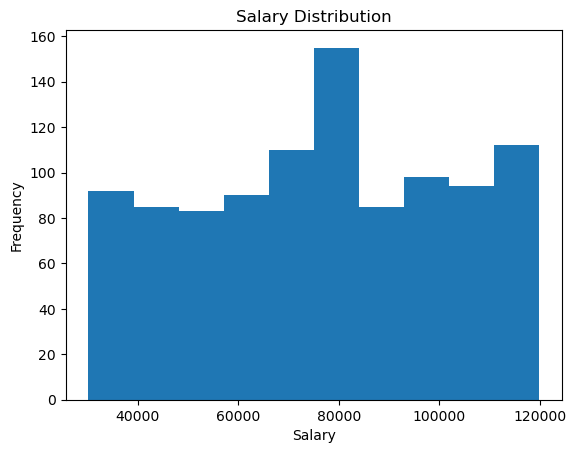

In [67]:
plt.hist(df["Salary"], bins=10)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.show()

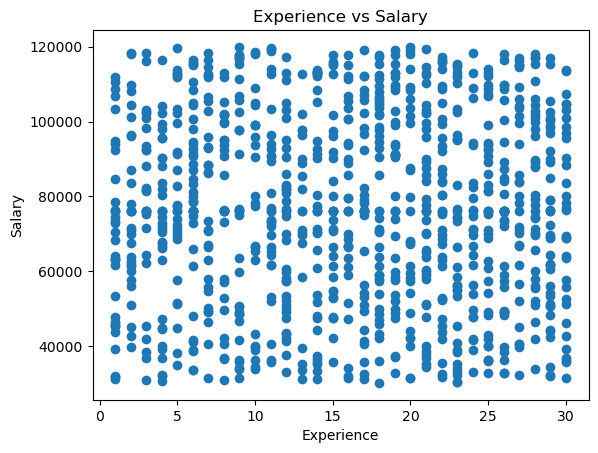

In [68]:
plt.scatter(df["Experience"], df["Salary"])

plt.title("Experience vs Salary")
plt.xlabel("Experience")
plt.ylabel("Salary")

plt.show()

In [69]:
# OBSERVATIONS

#1-Employees in the Finance department have one of the highest average salaries in the dataset.
#2-Most employees earn salaries in the middle salary range, while only a few employees earn extremely high salaries.
#3-Employees with more years of experience generally tend to earn higher salaries.
#4-The dataset contains employees from multiple cities with a fairly balanced distribution.
#5-Male and female employees have very similar average performance scores.